In [89]:
import pandas as pd
from braincoder.models import GaussianPRF

import numpy as np

from neural_priors.utils.data import Subject
from neural_priors.encoding_model2.fit_model import get_paradigm, get_model
from pathlib import Path

from braincoder.utils import get_rsq
from braincoder.utils.math import get_expected_value, get_sd_posterior
from braincoder.optimize import ResidualFitter
from tqdm.contrib.itertools import product
import seaborn as sns

import matplotlib.pyplot as plt

In [90]:
bids_folder = Path('/data/ds-neuralpriors')

subjects = list(range(1, 42))
subjects.remove(11)

model_labels =[31]
fit_responses = [False]
both_wide_priors= [False, True]

smoothed = True

E = []
sd = []
keys = [] 
pars = []

for subject, model_label, fit_response, spherical_noise, wide_prior in product(subjects, model_labels, fit_responses, [True], both_wide_priors):

        # Create target folder
    key = f'model{model_label}'

    if smoothed:
        key += '.smoothed'

    if spherical_noise:
        key += '.spherical_noise'

    if fit_response:
        key += '.fit_responses'

    if wide_prior:
        key += '.wide'

    target_dir = Path(bids_folder) / 'derivatives' / 'expected_uncertainty' / key / f'sub-{subject:02d}' / 'func'


    try:
    #     # fi = pd.read_csv(target_dir / f'sub-{subject:02d}_desc-fisher_information.tsv', sep='\t')

        pars.append(pd.read_csv(target_dir / f'sub-{subject:02d}_desc-expected_error.tsv', sep='\t', index_col=0))
    #     E.append(pd.read_csv(target_dir / f'sub-{subject:02d}_desc-expected_value.tsv', sep='\t'))
    #     sd.append(pd.read_csv(target_dir / f'sub-{subject:02d}_desc-sd.tsv', sep='\t'))
    except FileNotFoundError as e:
        print(f'File not found for subject {subject}, model {model_label}, fit_response {fit_response}: {e}')
    
        continue

    # fisher_information.append(fi)
    keys.append((subject , model_label, fit_response, smoothed, spherical_noise, wide_prior))

# Concatenate all dataframes
# fisher_information = pd.concat(fisher_information, keys=keys, names=['subject', 'model_label', 'fit_response', 'smoothed'])
# E = pd.concat(E, keys=keys, names=['subject', 'model_label', 'fit_response', 'smoothed', 'spherical_noise'])
# sd = pd.concat(sd, keys=keys, names=['subject', 'model_label', 'fit_response', 'smoothed', 'spherical_noise'])

pars = pd.concat(pars, keys=keys, names=['subject', 'model_label', 'fit_response', 'smoothed', 'spherical_noise', 'wide_prior'])
pars.xs(True, level='spherical_noise').to_csv(Path(bids_folder) / 'derivatives' / 'expected_uncertainty'  / 'expected_uncertainty.tsv', sep='\t')

  0%|          | 0/80 [00:00<?, ?it/s]

File not found for subject 23, model 31, fit_response False: [Errno 2] No such file or directory: '/data/ds-neuralpriors/derivatives/expected_uncertainty/model31.smoothed.spherical_noise/sub-23/func/sub-23_desc-expected_error.tsv'
File not found for subject 23, model 31, fit_response False: [Errno 2] No such file or directory: '/data/ds-neuralpriors/derivatives/expected_uncertainty/model31.smoothed.spherical_noise.wide/sub-23/func/sub-23_desc-expected_error.tsv'


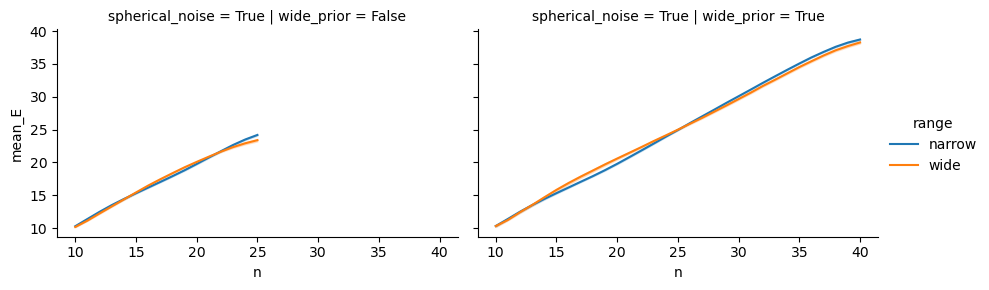

In [91]:
sns.relplot(x='n', y='mean_E', hue='range', data=pars.groupby(['subject', 'range', 'n', 'spherical_noise', 'wide_prior'])[['mean_E']].mean().reset_index(), errorbar='se', kind='line', height=3, aspect=1.5,
            col='wide_prior',
            row='spherical_noise')

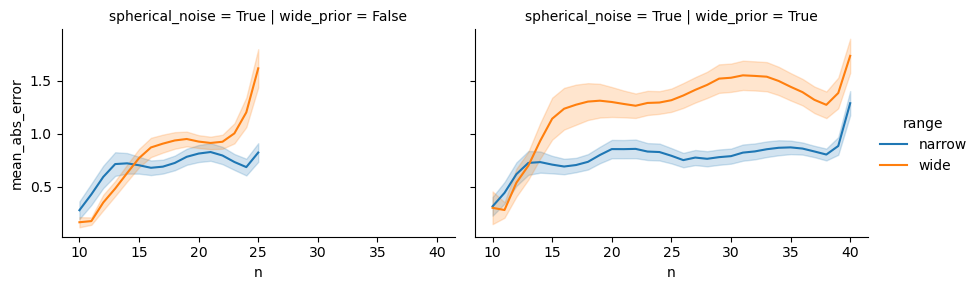

In [92]:
sns.relplot(x='n', y='mean_abs_error', hue='range', data=pars.groupby(['subject', 'range', 'n', 'spherical_noise', 'wide_prior'])[['mean_abs_error']].mean().reset_index(), errorbar='se', kind='line', height=3, aspect=1.5,
col='wide_prior', 
            row='spherical_noise')

# Only spherical noise

Text(0.5, 1.0, 'Variance of Expected value')

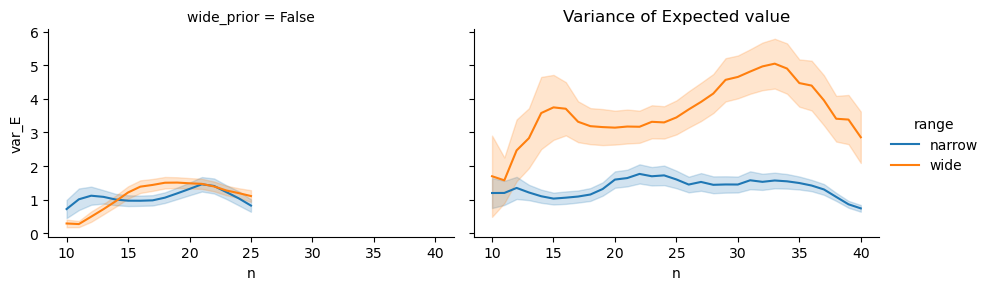

In [93]:
sns.relplot(x='n', y='var_E', hue='range', col='wide_prior', data=pars.groupby(['subject', 'range', 'n', 'wide_prior']).mean().reset_index(), errorbar='se', kind='line', height=3, aspect=1.5,)

plt.title("Variance of Expected value")

# only with spherical noise and narrow prior for narrow

In [94]:
pars = pars.xs(True, level='spherical_noise').xs(False, level='wide_prior')

In [95]:
pars.head()

n     mean_E  mean_error  \
subject model_label fit_response smoothed range                                 
1       31          False        True     narrow  10.0  10.497773    0.497774   
                                          narrow  11.0  11.106773    0.106774   
                                          narrow  12.0  12.152911    0.152911   
                                          narrow  13.0  13.158963    0.158963   
                                          narrow  14.0  14.232490    0.232489   

                                                     var_E  mean_abs_error  
subject model_label fit_response smoothed range                             
1       31          False        True     narrow  1.135848        0.497774  
                                          narrow  0.225290        0.164888  
                                          narrow  0.320103        0.280951  
                                          narrow  0.735248        0.526162  
                                          narrow  0.641316        0.594400

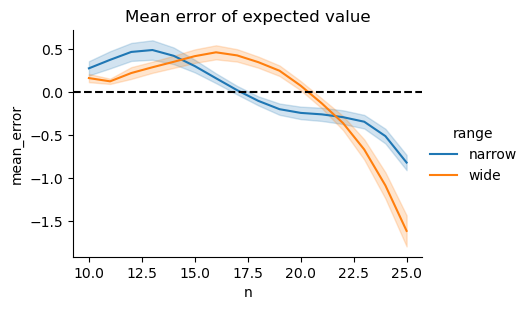

In [96]:
sns.relplot(x='n', y='mean_error', hue='range', data=pars.groupby(['subject', 'range', 'n']).mean().reset_index(), errorbar='se', kind='line', height=3, aspect=1.5,)

plt.title("Mean error of expected value")

plt.axhline(0, color='k', linestyle='--')

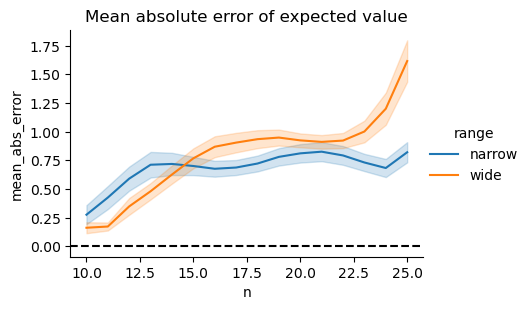

In [97]:
sns.relplot(x='n', y='mean_abs_error', hue='range', data=pars.groupby(['subject', 'range', 'n']).mean().reset_index(), errorbar='se', kind='line', height=3, aspect=1.5,)

plt.title("Mean absolute error of expected value")
plt.axhline(0, color='k', linestyle='--')

Text(0.5, 1.0, 'Variance of Expected value')

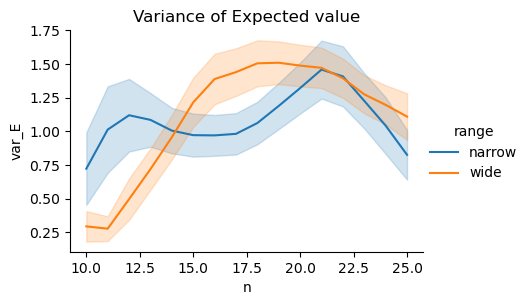

In [98]:
sns.relplot(x='n', y='var_E', hue='range', data=pars.groupby(['subject', 'range', 'n']).mean().reset_index(), errorbar='se', kind='line', height=3, aspect=1.5,)

plt.title("Variance of Expected value")